<a href="https://colab.research.google.com/github/alexaar/Appdesktop/blob/master/Copia_de_Caso_Turismo_Europa_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso de estudio: Análisis de tendencias turísticas en Europa 2023

Este notebook resuelve el caso usando **Pandas**, **Matplotlib** y, para las visualizaciones interactivas solicitadas, **Plotly Express**.

> Dataset esperado: `TablaTurismo.csv`

## 1. Cargar librerías y dataset

En Google Colab puedes subir el archivo `TablaTurismo.csv` al panel de archivos o ejecutar la celda de carga.

In [ ]:
# Dataset ya disponible en el entorno de ejecución
# En Google Colab, sube TablaTurismo.csv al panel de archivos antes de ejecutar.
import os
print('Archivo TablaTurismo.csv encontrado:', os.path.exists('TablaTurismo.csv'))

Archivo TablaTurismo.csv encontrado: True


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

# Configuración general de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

# Leer dataset
archivo = 'TablaTurismo.csv'
df = pd.read_csv(archivo)

# Vista inicial
df.head()


,fecha,pais,ciudad,latitud,longitud,tipo_alojamiento,duracion_estancia,gasto_diario,valoracion,transporte,motivo_viaje
0,2023-04-13,Francia,Lyon,45.7640,4.8357,Hostal,9,76.14,1,Tren,Vacaciones
1,2023-12-15,España,Málaga,36.7213,-4.4214,Apartamento,6,83.41,2,Tren,Vacaciones
2,2023-09-28,Francia,Burdeos,44.8378,-0.5792,Hostal,14,90.19,5,Coche,Vacaciones
3,2023-04-17,España,Sevilla,37.3891,-5.9845,Hotel,11,124.97,3,Coche,Vacaciones
4,2023-03-13,Francia,Lyon,45.7640,4.8357,Hotel,13,97.39,5,Tren,Vacaciones


## 2. Exploración y preparación de datos

In [ ]:
# Información general del dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              10000 non-null  object 
 1   pais               10000 non-null  object 
 2   ciudad             10000 non-null  object 
 3   latitud            10000 non-null  float64
 4   longitud           10000 non-null  float64
 5   tipo_alojamiento   10000 non-null  object 
 6   duracion_estancia  10000 non-null  int64  
 7   gasto_diario       10000 non-null  float64
 8   valoracion         10000 non-null  int64  
 9   transporte         10000 non-null  object 
 10  motivo_viaje       10000 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 859.5+ KB


In [ ]:
# Revisión de valores nulos
df.isnull().sum()


fecha                0
pais                 0
ciudad               0
latitud              0
longitud             0
tipo_alojamiento     0
duracion_estancia    0
gasto_diario         0
valoracion           0
transporte           0
motivo_viaje         0
dtype: int64

In [ ]:
# Convertir fecha a tipo datetime y crear columnas auxiliares para análisis mensual
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes_num'] = df['fecha'].dt.month

meses = {
    1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril',
    5:'Mayo', 6:'Junio', 7:'Julio', 8:'Agosto',
    9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'
}
df['mes'] = df['mes_num'].map(meses)

# Resumen estadístico
df.describe(include='all')


,fecha,pais,ciudad,latitud,longitud,tipo_alojamiento,duracion_estancia,gasto_diario,valoracion,transporte,motivo_viaje,mes_num,mes
count,10000,10000,10000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,5,25,NaN,NaN,5,NaN,NaN,NaN,4,4,NaN,12
top,NaN,Reino Unido,Burdeos,NaN,NaN,Hotel,NaN,NaN,NaN,Tren,Vacaciones,NaN,Abril
freq,NaN,2041,467,NaN,NaN,4055,NaN,NaN,NaN,2542,6990,NaN,869
mean,2023-06-30 22:08:06.720000,NaN,NaN,46.485798,4.131336,NaN,7.473300,100.071831,2.987800,NaN,NaN,6.491800,NaN
min,2023-01-01 00:00:00,NaN,NaN,36.721300,-5.984500,NaN,1.000000,20.000000,1.000000,NaN,NaN,1.000000,NaN
25%,2023-04-03 00:00:00,NaN,NaN,41.902800,-1.890400,NaN,4.000000,80.035000,2.000000,NaN,NaN,4.000000,NaN
50%,2023-06-30 00:00:00,NaN,NaN,45.464200,4.835700,NaN,7.000000,100.010000,3.000000,NaN,NaN,6.000000,NaN
75%,2023-09-30 00:00:00,NaN,NaN,51.507400,9.993700,NaN,11.000000,119.955000,4.000000,NaN,NaN,9.000000,NaN
max,2023-12-30 00:00:00,NaN,NaN,55.953300,14.268100,NaN,14.000000,222.980000,5.000000,NaN,NaN,12.000000,NaN


## 3. Visualización 1: Patrones estacionales de viaje

Gráfico de barras con el número de viajes por mes para identificar temporada alta y baja.

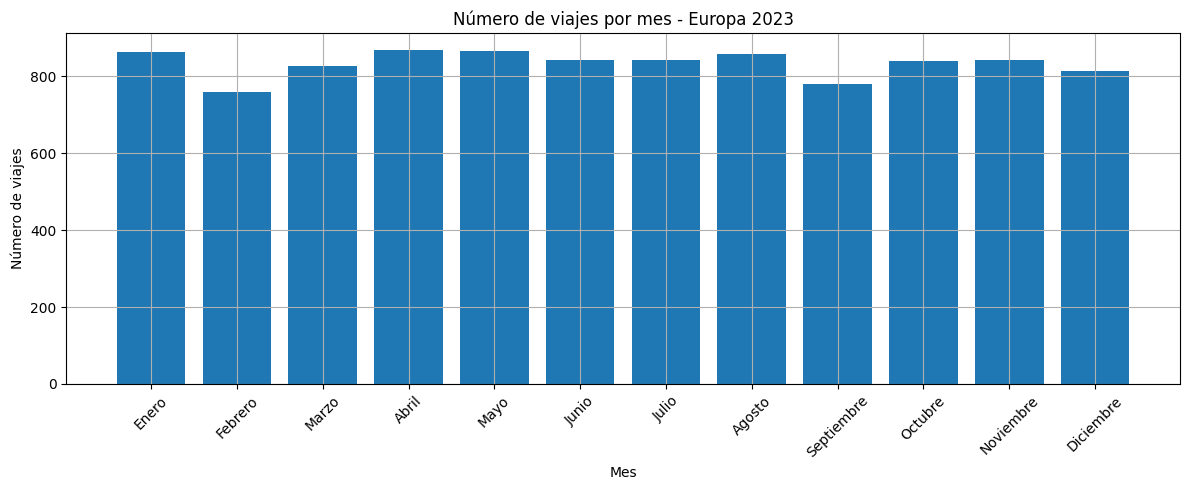

,mes_num,mes,numero_viajes
0,1,Enero,863
1,2,Febrero,759
2,3,Marzo,826
3,4,Abril,869
4,5,Mayo,866
5,6,Junio,842
6,7,Julio,841
7,8,Agosto,858
8,9,Septiembre,780
9,10,Octubre,840


In [ ]:
viajes_mes = (
    df.groupby(['mes_num', 'mes'])
      .size()
      .reset_index(name='numero_viajes')
      .sort_values('mes_num')
)

plt.figure(figsize=(12, 5))
plt.bar(viajes_mes['mes'], viajes_mes['numero_viajes'])
plt.title('Número de viajes por mes - Europa 2023')
plt.xlabel('Mes')
plt.ylabel('Número de viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

viajes_mes


## 4. Visualización 2: Destinos más populares

Gráfico de barras horizontales con las 10 ciudades más visitadas.

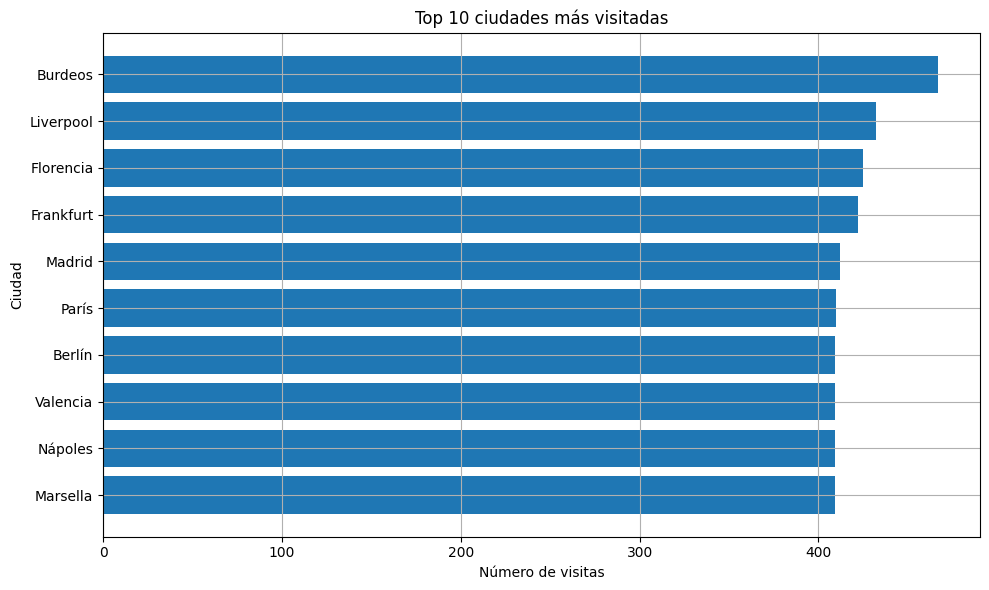

,count
ciudad,
Burdeos,467
Liverpool,432
Florencia,425
Frankfurt,422
Madrid,412
París,410
Nápoles,409
Marsella,409
Valencia,409


In [ ]:
top_ciudades = df['ciudad'].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_ciudades.index, top_ciudades.values)
plt.title('Top 10 ciudades más visitadas')
plt.xlabel('Número de visitas')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

top_ciudades.sort_values(ascending=False)


## 5. Visualización 3: Relación entre tipo de alojamiento y gasto diario

Diagrama de caja para comparar la distribución del gasto diario por tipo de alojamiento.

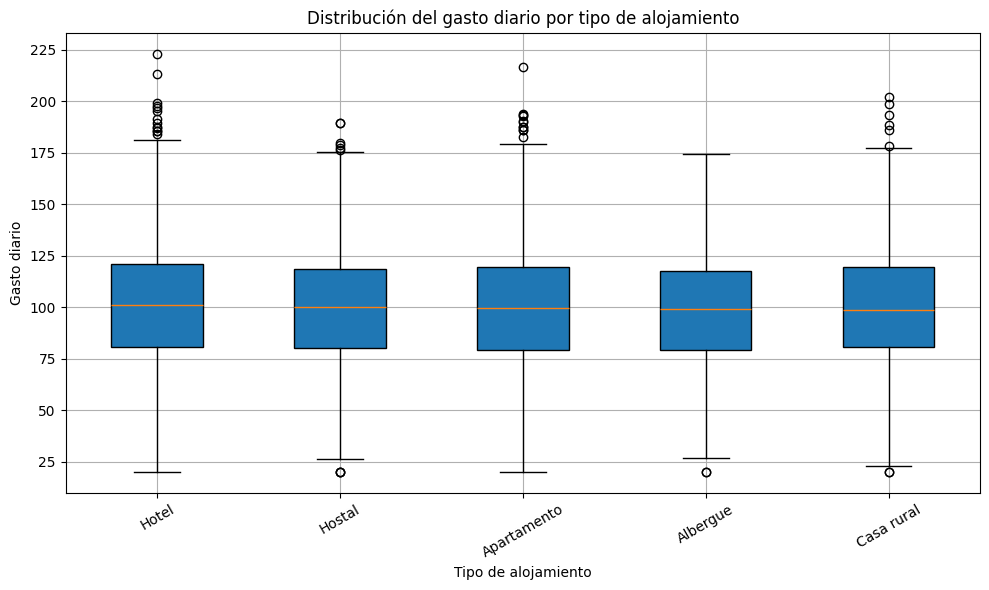

,count,mean,median,min,max
tipo_alojamiento,,,,,
Hotel,4055,100.66,101.01,20.0,222.98
Hostal,1469,99.78,100.14,20.0,189.60
Apartamento,3053,99.73,99.52,20.0,216.74
Casa rural,920,99.66,98.48,20.0,202.21
Albergue,503,98.97,99.28,20.0,174.31


In [ ]:
# Ordenar tipos de alojamiento por mediana del gasto diario
orden_alojamiento = (
    df.groupby('tipo_alojamiento')['gasto_diario']
      .median()
      .sort_values(ascending=False)
      .index
)

datos_box = [df.loc[df['tipo_alojamiento'] == tipo, 'gasto_diario'] for tipo in orden_alojamiento]

plt.figure(figsize=(10, 6))
plt.boxplot(datos_box, tick_labels=orden_alojamiento, patch_artist=True)
plt.title('Distribución del gasto diario por tipo de alojamiento')
plt.xlabel('Tipo de alojamiento')
plt.ylabel('Gasto diario')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

resumen_gasto = df.groupby('tipo_alojamiento')['gasto_diario'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
resumen_gasto.sort_values('mean', ascending=False)


## 6. Visualización 4: Satisfacción del cliente por país

Diagrama de caja interactivo con Plotly para analizar las valoraciones por país.

In [ ]:
fig = px.box(
    df,
    x='pais',
    y='valoracion',
    color='pais',
    title='Distribución de valoraciones por país',
    labels={'pais': 'País', 'valoracion': 'Valoración'}
)
fig.show()

resumen_valoracion = df.groupby('pais')['valoracion'].agg(['count', 'mean', 'median']).round(2)
resumen_valoracion.sort_values('mean', ascending=False)


,count,mean,median
pais,,,
Italia,1935,3.04,3.0
Alemania,1986,2.99,3.0
España,2000,2.99,3.0
Francia,2038,2.97,3.0
Reino Unido,2041,2.95,3.0


## 7. Visualización 5: Duración promedio de estancia por destino

Gráfico de barras interactivo que muestra el promedio de días de estancia por ciudad.

In [ ]:
duracion_ciudad = (
    df.groupby('ciudad', as_index=False)['duracion_estancia']
      .mean()
      .sort_values('duracion_estancia', ascending=False)
)

fig = px.bar(
    duracion_ciudad,
    x='ciudad',
    y='duracion_estancia',
    title='Duración promedio de estancia por ciudad',
    labels={'ciudad': 'Ciudad', 'duracion_estancia': 'Duración promedio de estancia'}
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

duracion_ciudad.head(10)


,ciudad,duracion_estancia
24,Venecia,7.934066
6,Florencia,7.868235
11,Lyon,7.735751
22,Sevilla,7.731646
18,Niza,7.674863
13,Manchester,7.605911
4,Colonia,7.600496
5,Edimburgo,7.567901
20,París,7.500000
19,Nápoles,7.474328


## 8. Visualización 6: Distribución geográfica de los viajes

Mapa interactivo donde el color representa el país y el tamaño del punto representa la duración de la estancia.

In [ ]:
fig = px.scatter_mapbox(
    df,
    lat='latitud',
    lon='longitud',
    color='pais',
    size='duracion_estancia',
    hover_name='ciudad',
    hover_data=['fecha', 'tipo_alojamiento', 'gasto_diario', 'valoracion', 'motivo_viaje'],
    zoom=3,
    height=650,
    title='Distribución geográfica de viajes en Europa 2023'
)
fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(margin={'r':0, 't':50, 'l':0, 'b':0})
fig.show()


## 9. Insights principales del análisis

In [ ]:
# Cálculos automáticos para redactar conclusiones
mes_mas_alto = viajes_mes.loc[viajes_mes['numero_viajes'].idxmax()]
mes_mas_bajo = viajes_mes.loc[viajes_mes['numero_viajes'].idxmin()]
ciudad_top = df['ciudad'].value_counts().idxmax()
visitas_ciudad_top = df['ciudad'].value_counts().max()
pais_mejor_valorado = resumen_valoracion['mean'].idxmax()
valoracion_media_top = resumen_valoracion.loc[pais_mejor_valorado, 'mean']
ciudad_mayor_estancia = duracion_ciudad.iloc[0]['ciudad']
prom_mayor_estancia = duracion_ciudad.iloc[0]['duracion_estancia']
alojamiento_mayor_gasto = resumen_gasto['mean'].idxmax()
gasto_medio_top = resumen_gasto.loc[alojamiento_mayor_gasto, 'mean']

print('Conclusiones sugeridas:')
print(f"1. El mes con mayor número de viajes es {mes_mas_alto['mes']} con {mes_mas_alto['numero_viajes']} viajes.")
print(f"2. El mes con menor número de viajes es {mes_mas_bajo['mes']} con {mes_mas_bajo['numero_viajes']} viajes.")
print(f"3. La ciudad más visitada es {ciudad_top} con {visitas_ciudad_top} visitas.")
print(f"4. El tipo de alojamiento con mayor gasto diario promedio es {alojamiento_mayor_gasto}, con un promedio de {gasto_medio_top:.2f}.")
print(f"5. El país con mejor valoración promedio es {pais_mejor_valorado}, con una media de {valoracion_media_top:.2f}.")
print(f"6. La ciudad con mayor duración promedio de estancia es {ciudad_mayor_estancia}, con {prom_mayor_estancia:.2f} días.")


Conclusiones sugeridas:
1. El mes con mayor número de viajes es Abril con 869 viajes.
2. El mes con menor número de viajes es Febrero con 759 viajes.
3. La ciudad más visitada es Burdeos con 467 visitas.
4. El tipo de alojamiento con mayor gasto diario promedio es Hotel, con un promedio de 100.66.
5. El país con mejor valoración promedio es Italia, con una media de 3.04.
6. La ciudad con mayor duración promedio de estancia es Venecia, con 7.93 días.


## 10. Conclusión para el informe

Las visualizaciones permiten identificar patrones de comportamiento turístico en Europa durante 2023. El análisis mensual ayuda a reconocer temporadas de mayor y menor demanda; el ranking de ciudades evidencia los destinos más atractivos; los diagramas de caja permiten comparar gasto y satisfacción; y el mapa interactivo facilita la comprensión espacial de los viajes. Estos resultados pueden apoyar decisiones de marketing, diseño de paquetes turísticos, segmentación de clientes y priorización de destinos.